# Outlier Removal by IQR
* used when data is right/left skewed
dataset.
* Box plot is used , (IOR)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(r'c:\Users\rajku\Downloads\placement.csv')

In [6]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


C:\Users\rajku\AppData\Local\Temp\ipykernel_10476\2988776511.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\rajku\AppData\Local\Temp\ipykernel_10476\2988776511.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


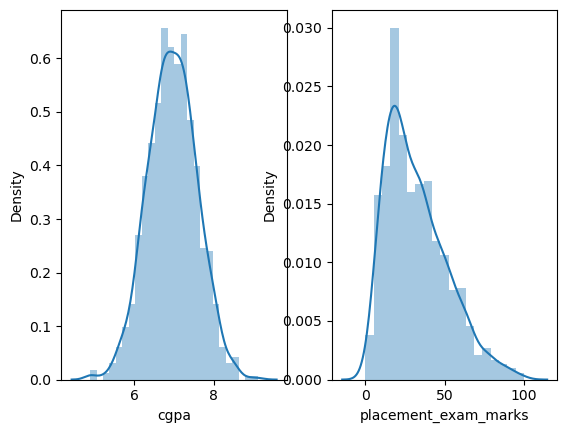

In [7]:
plt.Figure(figsize=(16,5))
plt.subplot(121)
sns.distplot(df['cgpa'])

plt.subplot(122)
sns.distplot(df['placement_exam_marks'])
plt.show()


In [8]:
df['placement_exam_marks'].skew()       # +ve means right skewd

np.float64(0.8356419499466834)

In [9]:
df['placement_exam_marks'].describe()       

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: xlabel='placement_exam_marks'>

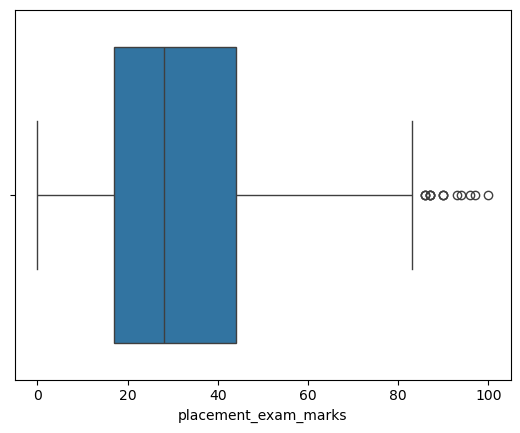

In [10]:
sns.boxplot(x= df['placement_exam_marks'])

In [11]:
prec25 = df['placement_exam_marks'].quantile(.25)
prec75 = df['placement_exam_marks'].quantile(.75)

In [14]:
prec25

np.float64(17.0)

In [15]:
iqr = prec75 - prec25

In [16]:
iqr

np.float64(27.0)

In [17]:
print('lower bound : ', prec25 - 1.5*iqr)
print('Upper bound : ', 1.5*iqr + prec75)


lower bound :  -23.5
Upper bound :  84.5


In [ ]:
df[df['placement_exam_marks'] > 84.5] # outliers

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [26]:
new_df = df[df['placement_exam_marks'] < 84.5]
df.shape

(1000, 3)

In [27]:
new_df.shape

(985, 3)

<Axes: xlabel='placement_exam_marks'>

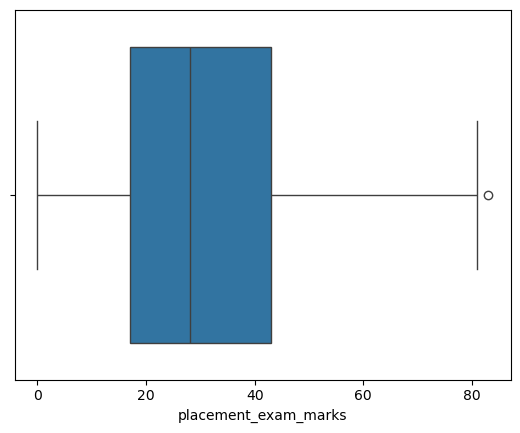

In [28]:
sns.boxplot(x= new_df['placement_exam_marks'])

# Capping

In [ ]:
# if new_df[df['placement_exam_marks'] > 84.5] then replace with 84.5
# else no change

C:\Users\rajku\AppData\Local\Temp\ipykernel_10476\2051048649.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\rajku\AppData\Local\Temp\ipykernel_10476\2051048649.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['placement_exam_marks'])


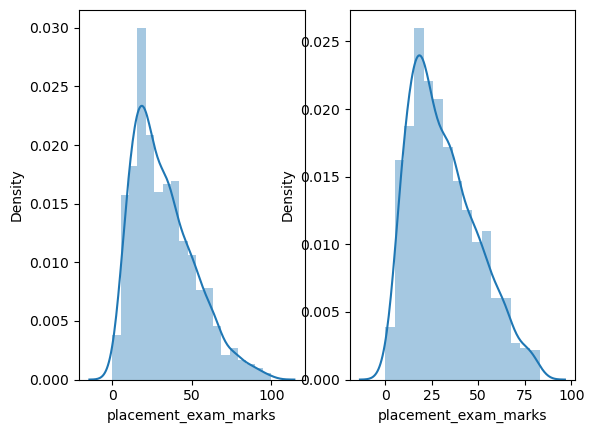

In [31]:
plt.Figure(figsize=(16,5))
plt.subplot(121)
sns.distplot(df['placement_exam_marks'])

plt.subplot(122)
sns.distplot(new_df['placement_exam_marks'])
plt.show()
